In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

sys.path.append(str(Path("../pricers").resolve()))

from black76 import black76_call, call_spread_price

In [2]:
ticker = "CL=F"
start_date = "2024-01-01"

cl = yf.download(ticker, start=start_date, auto_adjust=False, progress=False)
cl.columns = [col[0] if isinstance(col, tuple) else col for col in cl.columns]
cl = cl[["Close"]].rename(columns={"Close": "close"}).dropna()

cl.tail()

,close
Date,
2026-04-23,95.849998
2026-04-24,94.400002
2026-04-27,96.370003
2026-04-28,99.930000
2026-04-29,103.910004


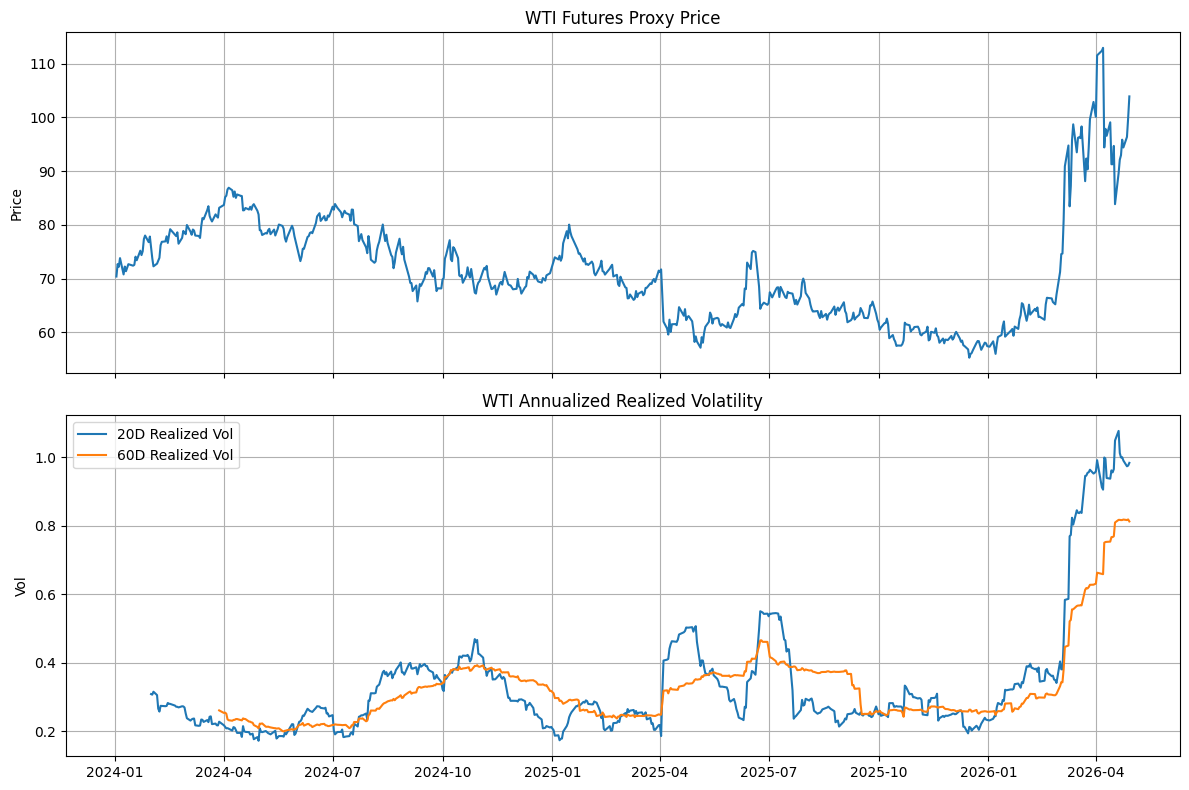

In [3]:
cl["ret"] = cl["close"].pct_change()
cl["rv_20"] = cl["ret"].rolling(20).std() * np.sqrt(252)
cl["rv_60"] = cl["ret"].rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(cl.index, cl["close"])
ax[0].set_title("WTI Futures Proxy Price")
ax[0].set_ylabel("Price")
ax[0].grid(True)

ax[1].plot(cl.index, cl["rv_20"], label="20D Realized Vol")
ax[1].plot(cl.index, cl["rv_60"], label="60D Realized Vol")
ax[1].set_title("WTI Annualized Realized Volatility")
ax[1].set_ylabel("Vol")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
long_call = black76_call(F, K1, T, r, sigma)
short_call = black76_call(F, K2, T, r, sigma)
spread_price = call_spread_price(F, K1, K2, T, r, sigma)

print("Long call price:", round(long_call, 4))
print("Short call price:", round(short_call, 4))
print("Call spread price:", round(spread_price, 4))

Long call price: 7.9254
Short call price: 6.6355
Call spread price: 1.2898


In [6]:
max_payoff = K2 - K1
max_profit = max_payoff - spread_price
max_loss = spread_price
breakeven = K1 + spread_price

print("Max payoff:", round(max_payoff, 4))
print("Max profit:", round(max_profit, 4))
print("Max loss:", round(max_loss, 4))
print("Breakeven:", round(breakeven, 4))

Max payoff: 3
Max profit: 1.7102
Max loss: 1.2898
Breakeven: 105.2898


In [7]:
cl["abs_move"] = cl["close"].diff().abs()
cl["move_5d"] = (cl["close"] - cl["close"].shift(5)).abs()

avg_1d_move_20 = cl["abs_move"].rolling(20).mean().iloc[-1]
avg_5d_move_20 = cl["move_5d"].rolling(20).mean().iloc[-1]
max_5d_move_60 = cl["move_5d"].rolling(60).max().iloc[-1]

print("Average 1D absolute move (20D):", round(avg_1d_move_20, 4))
print("Average 5D absolute move (20D):", round(avg_5d_move_20, 4))
print("Max 5D absolute move (60D):", round(max_5d_move_60, 4))
print("Breakeven move needed:", round(breakeven - F, 4))

Average 1D absolute move (20D): 4.2455
Average 5D absolute move (20D): 8.856
Max 5D absolute move (60D): 23.88
Breakeven move needed: 1.3798


In [8]:
required_move = breakeven - F

print("Required move / avg 1D move:", round(required_move / avg_1d_move_20, 3))
print("Required move / avg 5D move:", round(required_move / avg_5d_move_20, 3))
print("Required move / max 5D move:", round(required_move / max_5d_move_60, 3))

Required move / avg 1D move: 0.325
Required move / avg 5D move: 0.156
Required move / max 5D move: 0.058


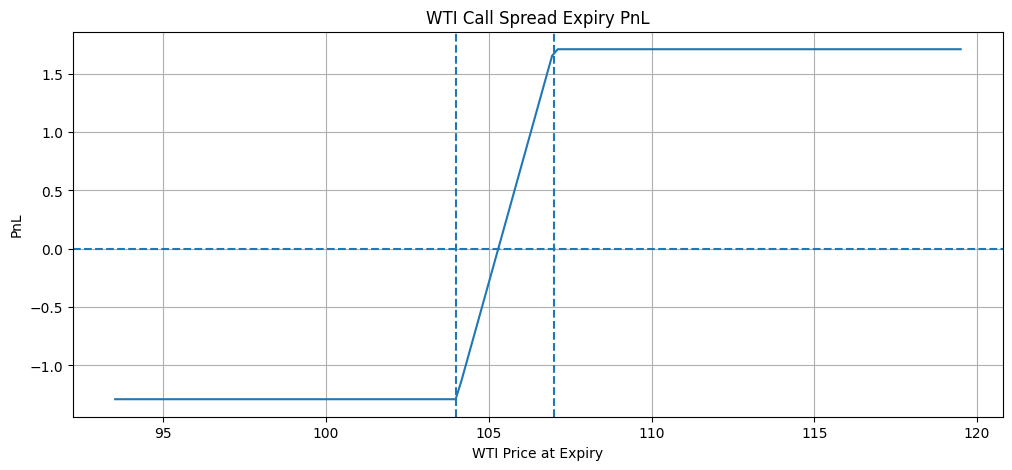

In [9]:
price_grid = np.linspace(F * 0.9, F * 1.15, 150)

pnl = []
for FT in price_grid:
    payoff = max(FT - K1, 0) - max(FT - K2, 0)
    pnl.append(payoff - spread_price)

pnl_df = pd.DataFrame({"F_T": price_grid, "PnL": pnl})

plt.figure(figsize=(12, 5))
plt.plot(pnl_df["F_T"], pnl_df["PnL"])
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--")
plt.axvline(K2, linestyle="--")
plt.title("WTI Call Spread Expiry PnL")
plt.xlabel("WTI Price at Expiry")
plt.ylabel("PnL")
plt.grid(True)
plt.show()

In [10]:
if required_move < avg_5d_move_20:
    print("Preliminary signal: call spread looks attractively priced relative to recent 5D oil moves.")
else:
    print("Preliminary signal: call spread may require a larger-than-average 5D oil move to work.")

Preliminary signal: call spread looks attractively priced relative to recent 5D oil moves.


## Preliminary pre-trade conclusion

This notebook evaluates whether a bullish WTI call spread is attractive by comparing the breakeven move implied by the spread cost with recent realized oil price moves. The structure becomes more attractive if the required move is small relative to recent multi-day realized moves and if the macro backdrop supports upside oil risk. It becomes less attractive if the breakeven requires an unusually large move or if recent oil volatility has already normalized.

In [11]:
for upper_strike in [107, 108, 109]:
    spread_price = call_spread_price(F, K1, upper_strike, T, r, sigma)
    max_payoff = upper_strike - K1
    max_profit = max_payoff - spread_price
    breakeven = K1 + spread_price
    
    print(f"K1={K1}, K2={upper_strike}")
    print("  Spread price:", round(spread_price, 4))
    print("  Max profit:", round(max_profit, 4))
    print("  Breakeven:", round(breakeven, 4))

K1=104, K2=107
  Spread price: 1.2898
  Max profit: 1.7102
  Breakeven: 105.2898
K1=104, K2=108
  Spread price: 1.6818
  Max profit: 2.3182
  Breakeven: 105.6818
K1=104, K2=109
  Spread price: 2.0555
  Max profit: 2.9445
  Breakeven: 106.0555


### Strike selection conclusion

A wider call spread improves the upside payoff but increases the upfront premium and pushes the breakeven further away. Among the tested structures, the 104/108 spread appears to offer the best balance between cost, breakeven distance, and upside participation. The 104/107 spread is the most conservative version, while the 104/109 spread is a more aggressive expression requiring a larger follow-through move in oil.